#EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/MCI/student_habits_performance.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [ ]:
for col in data.select_dtypes(include=['object', 'category']).columns:
    print(f"=== {col} ===")
    print(data[col].value_counts(dropna=False))
    print("\n")


=== student_id ===
student_id
S1999    1
S1000    1
S1001    1
S1002    1
S1003    1
        ..
S1012    1
S1011    1
S1010    1
S1009    1
S1008    1
Name: count, Length: 1000, dtype: int64


=== gender ===
gender
Female    481
Male      477
Other      42
Name: count, dtype: int64


=== part_time_job ===
part_time_job
No     785
Yes    215
Name: count, dtype: int64


=== diet_quality ===
diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64


=== parental_education_level ===
parental_education_level
High School    392
Bachelor       350
Master         167
NaN             91
Name: count, dtype: int64


=== internet_quality ===
internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64


=== extracurricular_participation ===
extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64




In [ ]:
data.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [ ]:
data.shape

(1000, 16)

In [ ]:
data.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


Text(0.5, 1.0, 'Heatmap Korelasi Antar Variabel')

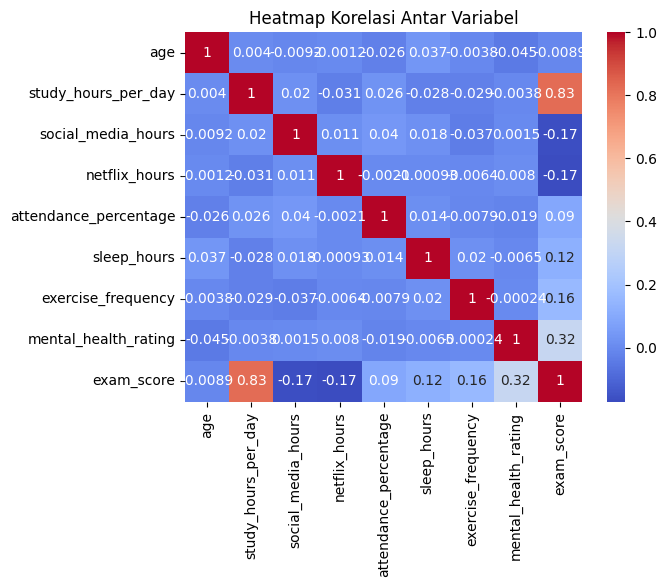

In [ ]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Antar Variabel")


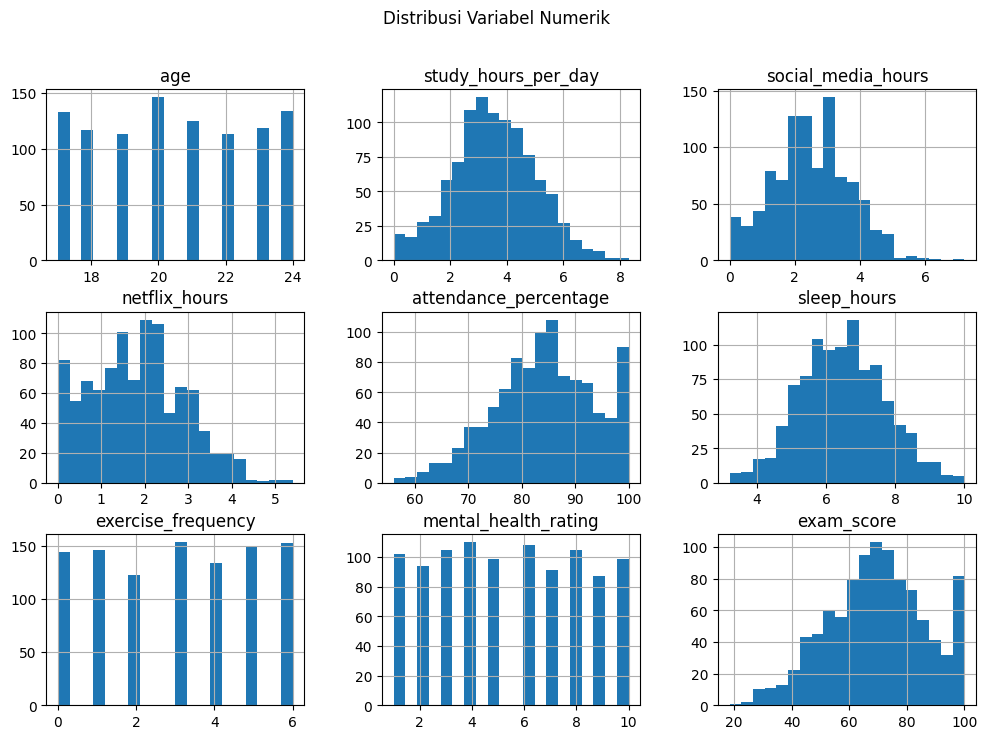

In [ ]:
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribusi Variabel Numerik")
plt.show()


/tmp/ipython-input-1393870150.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, ax=axes[i], order=value_counts.index, palette='pastel')
/tmp/ipython-input-1393870150.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, ax=axes[i], order=value_counts.index, palette='pastel')
/tmp/ipython-input-1393870150.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, ax=axes[i], order=value_counts.index, palette='pastel')
/tmp/ipython-input-1393870150.py:9: FutureWarning: 

Passing `palette` wi

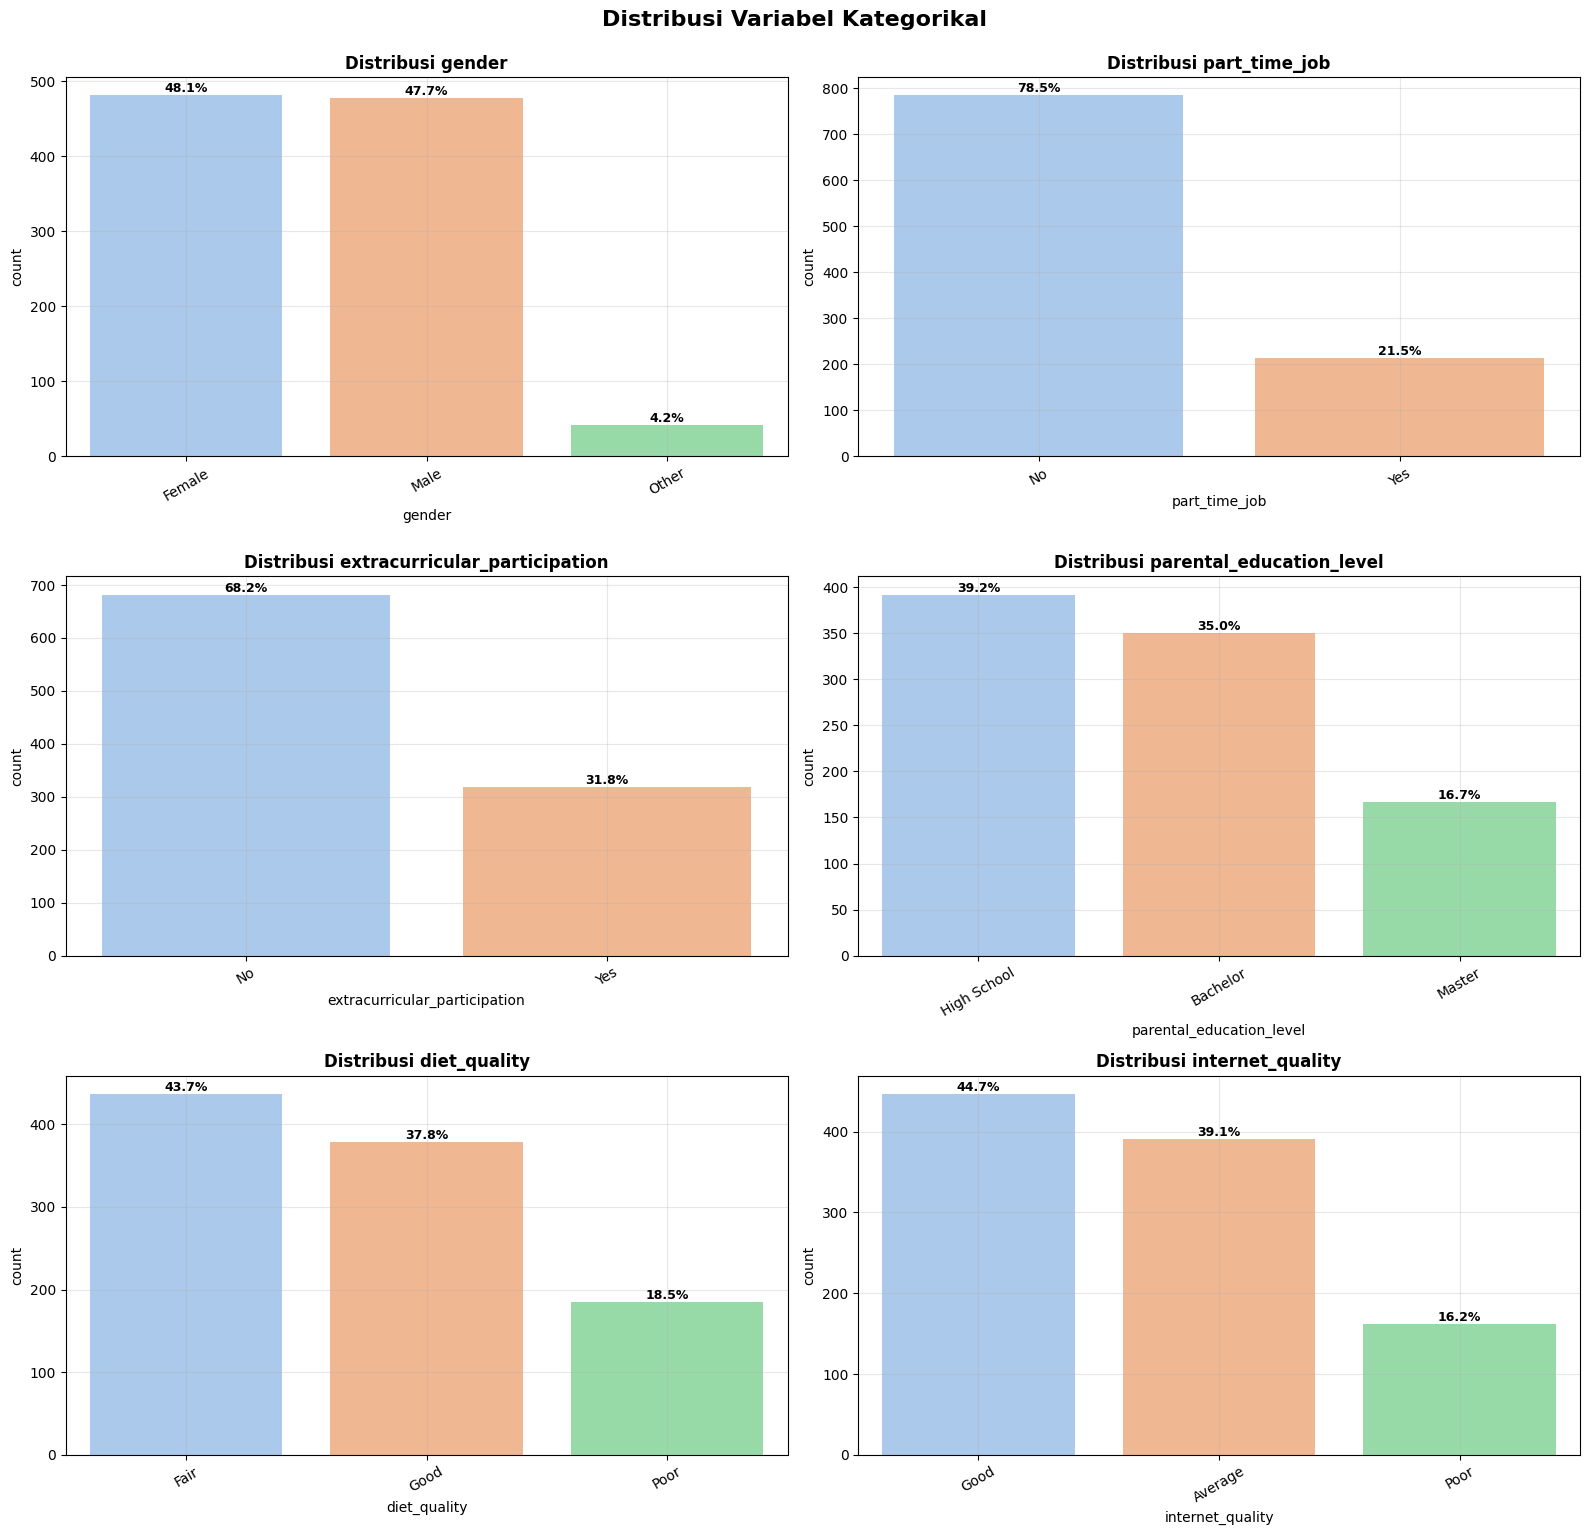

In [ ]:
categorical_cols = ['gender', 'part_time_job', 'extracurricular_participation', 'parental_education_level', 'diet_quality', 'internet_quality']
n_categorical = len(categorical_cols)
n_rows = (n_categorical + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    value_counts = data[col].value_counts()
    sns.countplot(data=data, x=col, ax=axes[i], order=value_counts.index, palette='pastel')
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(True, alpha=0.3)

    total = len(data)
    for p in axes[i].patches:
        height = p.get_height()
        percentage = f'{100 * height / total:.1f}%'
        axes[i].annotate(percentage,
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom',
                         fontsize=9, fontweight='bold')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribusi Variabel Kategorikal', fontsize=16, fontweight='bold', y=1.02)
plt.show()



# **Cleaning**

## Missing Values

In [ ]:
data['parental_education_level'] = data['parental_education_level'].fillna('Unknown')

print("\nSetelah perbaikan missing values:")
print(data['parental_education_level'].value_counts())


Setelah perbaikan missing values:
parental_education_level
High School    392
Bachelor       350
Master         167
Unknown         91
Name: count, dtype: int64


## Irrelevant data

In [ ]:
data = data[data['gender'] != 'Other']

print("\nSetelah menghapus 'Other' di kolom 'gender':")
print(data['gender'].value_counts())


Setelah menghapus 'Other' di kolom 'gender':
gender
Female    481
Male      477
Name: count, dtype: int64


## Outlier

In [ ]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
outlier_dict = {}

for col in numeric_cols:
    if col == 'exam_score':
        continue

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    bawah = Q1 - 1.5 * IQR
    atas  = Q3 + 1.5 * IQR

    outlier_rows = data[(data[col] < bawah) | (data[col] > atas)]
    outlier_dict[col] = int(outlier_rows.shape[0])

outlier_dict


{'age': 0,
 'study_hours_per_day': 3,
 'social_media_hours': 5,
 'netflix_hours': 3,
 'attendance_percentage': 3,
 'sleep_hours': 2,
 'exercise_frequency': 0,
 'mental_health_rating': 0}

In [ ]:
for col in numeric_cols:
      if col == 'exam_score':
        continue
    data[col] = pd.to_numeric(data[col], errors='coerce')


    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    bawah = Q1 - 1.5 * IQR
    atas  = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower=bawah, upper=atas)

    print(f"Winsorized {col}: lower={bawah:.3f}, upper={atas:.3f}")

plt.figure(figsize=(12,6))
sns.boxplot(data=data[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot Setelah Winsorizing Outlier")
plt.tight_layout()
plt.show()

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 4)

## Duplicate Data

In [ ]:
total_rows = data.shape[0]
cols_to_check = [col for col in data.columns if col != 'student_id']
duplicate_rows = data[data.duplicated(subset=cols_to_check, keep=False)]

print(f"Total baris dalam dataset: {total_rows}")
print(f"Jumlah baris duplikat (identik di semua kolom): {duplicate_rows.shape[0]}")

if 'student_id' in data.columns:
    dup_id_mask = data.duplicated(subset=['student_id'], keep=False)
    num_dup_ids = dup_id_mask.sum()
    print(f"\nJumlah baris yang memiliki student_id duplikat: {num_dup_ids}")

    if num_dup_ids > 0:
        display(data[dup_id_mask].sort_values('student_id').head(30))

if not duplicate_rows.empty:
    print("\nContoh baris duplikat:")
    display(duplicate_rows.sort_values(list(data.columns)).head(20))
else:
    print("\nTidak ada baris duplikat yang identik di semua kolom.")





# **Analyze and visualize relationships**


## Jam belajar dan nilai

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='study_hours_per_day', y='exam_score', hue='gender', data=data)
plt.title("Hubungan Jam Belajar dan Nilai Ujian Berdasarkan Gender")
plt.xlabel("Jam Belajar per Hari")
plt.ylabel("Nilai Ujian")
plt.show()

# Insight:
# Mahasiswa yang belajar lebih dari 5 jam/hari cenderung memiliki nilai >80.



In [ ]:
sns.lineplot(data=data, x='sleep_hours', y='exam_score')
plt.title("Hubungan Nilai Ujian dan Jam Tidur")
data[(data['exam_score'] == 90) & (data['sleep_hours'] == 3)]

# Hubungan antara lama tidur dan nilai ujian menunjukkan bahwa:
# Tidur terlalu sedikit (<5 jam) cenderung menurunkan nilai ujian.
# Tidur cukup (sekitar 6–8 jam) menghasilkan performa akademik yang stabil dan relatif tinggi.
# Tidur terlalu lama (>9 jam) tidak selalu meningkatkan performa, malah bisa fluktuatif.
# Kesimpulan umum:
# “Tidur cukup memiliki hubungan positif dengan performa akademik mahasiswa, sedangkan kurang tidur atau tidur berlebihan cenderung berkorelasi negatif terhadap hasil ujian.”



In [ ]:
data['social_media_level'] = pd.cut(
    data['social_media_hours'],
    bins=[0, 2, 4, 6],
    labels=['Rendah', 'Sedang', 'Tinggi']
)

sns.boxplot(data=data, x='social_media_level', y='exam_score')
plt.title('Perbandingan Nilai Ujian Berdasarkan Intensitas Media Sosial')
plt.show()

# Hasil dari visualisasi ini, terbagi dalam 'Rendah','Sedang', dan 'Tinggi'
# Berdasarkan visualisasi ini, terlihat bahwa semakin sering pelajar menggunakan sosial media ini berpengaruh ke nilai mereka. Semakin sering mereka berinteraksi dengannya,
# bisa mengurangi kualitas nilai mereka.



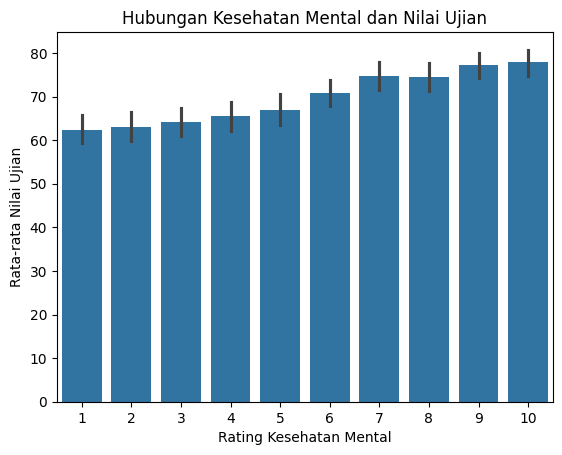

In [ ]:
sns.barplot(
    data=data,
    x='mental_health_rating',
    y='exam_score',
)

plt.title('Hubungan Kesehatan Mental dan Nilai Ujian')
plt.xlabel('Rating Kesehatan Mental')
plt.ylabel('Rata-rata Nilai Ujian')
plt.show()

# Dari hasil visualisasi dibawah, didapatkan bahwa kesehatan menttal

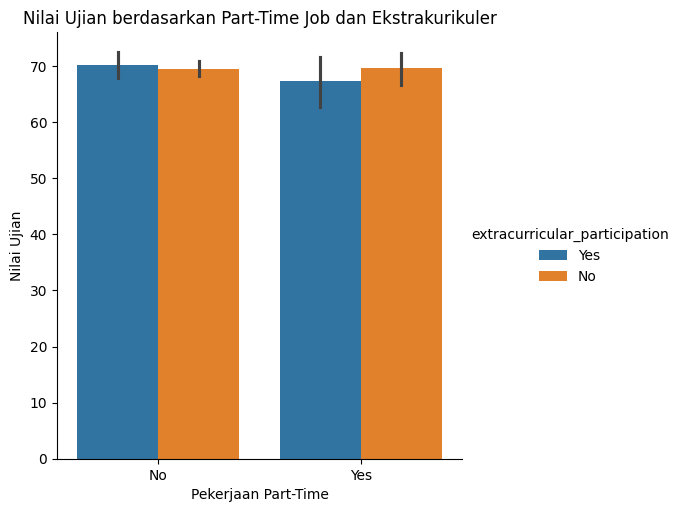

In [ ]:
sns.catplot(
    data=data,
    x='part_time_job',
    y='exam_score',
    hue='extracurricular_participation',
    kind='bar'
)
plt.title('Nilai Ujian berdasarkan Part-Time Job dan Ekstrakurikuler')
plt.xlabel('Pekerjaan Part-Time')
plt.ylabel('Nilai Ujian')
plt.show()

In [ ]:
sns.barplot(
   data=data,
   x='parental_education_level',
   y='exam_score'
)

plt.title('Hubungan Nilai Ujian dan Pendidikan Orang Tua')
plt.xlabel('Pendidikan Orang Tua')
plt.ylabel('Rata-rata Nilai Ujian')
plt.show()

In [ ]:
sns.lineplot(data=data, x='netflix_hours', y='exam_score')
plt.title("Hubungan Nilai Ujian dan Jam Tonton Netflix")

# Dapat disimpulkan dari grafik dibawah, rata-rata pelajar dengan semakin banyaknya mereka menghabiskan waktu menonton netflix
# maka hasil dari nilai ujian cenderung menurun